In [52]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("../src")
from utils import create_theme_and_change_plot_params

FE_DF_PATH = Path("../data/processed/online_retail_feature_engineered.parquet")
CUST_SEGM_PATH = Path("../data/processed/customer_segmentation.parquet")
fe_df = pd.read_parquet(FE_DF_PATH)
cust_segm_df = pd.read_parquet(CUST_SEGM_PATH)

# Cleaned Dataframe

In [53]:
# info about the cleaned df
fe_df.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085,United Kingdom,83.399994,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.000000,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085,United Kingdom,81.000000,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085,United Kingdom,100.799995,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085,United Kingdom,30.000000,2009,12,1


In [54]:
# info
fe_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 504731 entries, 0 to 504730
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   Invoice      504731 non-null  string  
 1   StockCode    504731 non-null  string  
 2   Description  504731 non-null  string  
 3   Quantity     504731 non-null  int16   
 4   Price        504731 non-null  float32 
 5   Customer ID  400916 non-null  Int64   
 6   Country      504731 non-null  category
 7   Revenue      504731 non-null  float32 
 8   Year         504731 non-null  int32   
 9   Month        504731 non-null  int32   
 10  Day          504731 non-null  int32   
dtypes: Int64(1), category(1), float32(2), int16(1), int32(3), string(3)
memory usage: 45.2 MB


In [55]:
# shape
fe_df.shape

(504731, 11)

## Cleaned dataframe EDA

In [56]:
# basic stats
fe_df.describe(include="number")

,Quantity,Price,Customer ID,Revenue,Year,Month,Day
count,504731.000000,504731.000000,400916.0,504731.000000,504731.000000,504731.000000,504731.000000
mean,11.516923,4.274692,15361.544074,20.351704,2009.913909,7.446477,15.261218
std,87.337497,64.093330,1680.635823,91.510979,0.280499,3.541718,8.696201
min,1.000000,0.001000,12346.0,0.001000,2009.000000,1.000000,1.000000
25%,1.000000,1.250000,13985.0,4.200000,2010.000000,4.000000,8.000000
50%,3.000000,2.100000,15311.0,10.200001,2010.000000,8.000000,15.000000
75%,12.000000,4.210000,16805.0,17.700001,2010.000000,11.000000,23.000000
max,19152.000000,25111.089844,18287.0,25111.089844,2010.000000,12.000000,31.000000


In [57]:
# set up theme and plot params
create_theme_and_change_plot_params()

### Missing Values Analysis

How many customer IDs are missing?

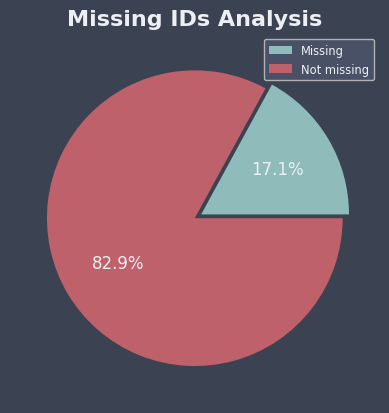

In [58]:
ids_missing_count = fe_df["Customer ID"].isna().sum()
fe_df_rows, cleaned_df_cols = fe_df.shape

plt.pie([ids_missing_count, fe_df_rows], autopct="%1.1f%%", explode=(0.05, 0))
plt.title("Missing IDs Analysis")
plt.legend(["Missing", "Not missing"], fontsize="x-small")
plt.show()

Do anonymous customers spend differently?

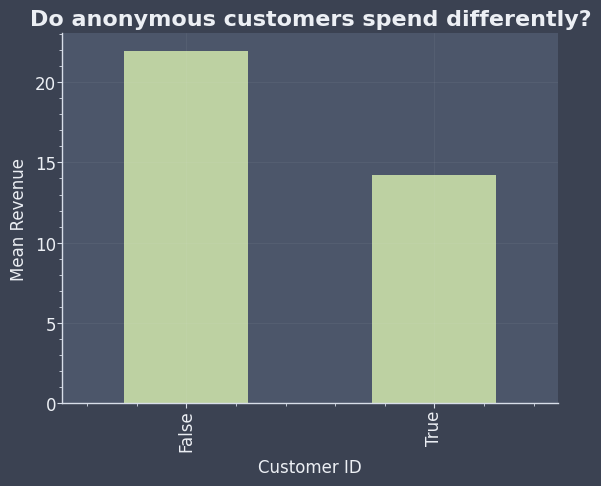

In [59]:
missing_ids = fe_df["Customer ID"].isna()
fe_df.groupby(missing_ids).Revenue.mean().plot(kind="bar", color="#bdd1a2", 
                                               title="Do anonymous customers spend differently?",
                                               ylabel="Mean Revenue")
plt.show()

### Numerical Feature Analysis

What is the revenue distribution?

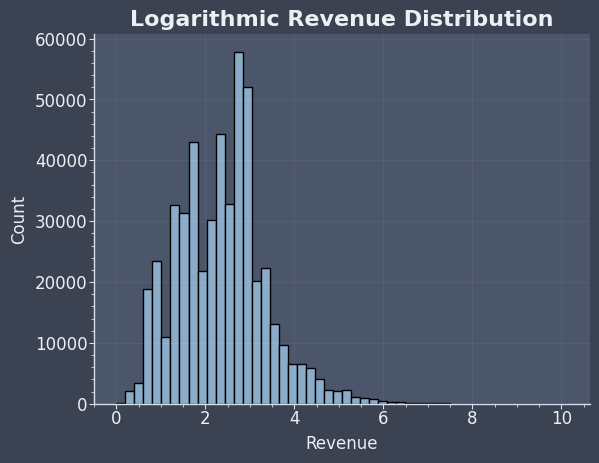

In [60]:
plt.hist(np.log1p(fe_df.Revenue), bins=50, edgecolor="black", color="#8bacc9")
plt.title("Logarithmic Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

Which months generate the most money?

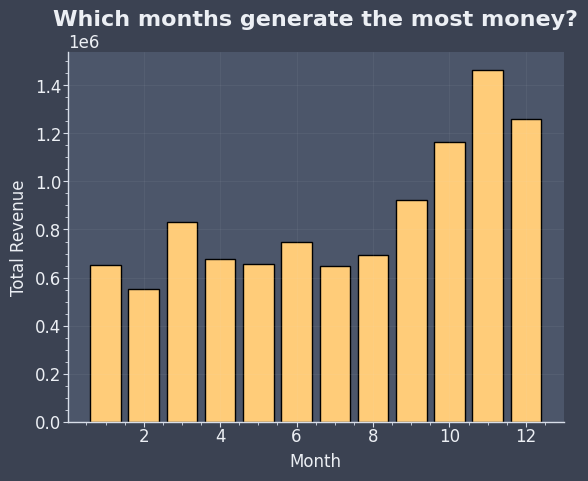

In [61]:
revenue_by_month = fe_df.groupby("Month").Revenue.sum()
plt.bar(revenue_by_month.index, revenue_by_month.values, color="#ffcc79", edgecolor="black")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Which months generate the most money?")
plt.show()

Do people buy many items? Also, do they buy high-priced items?

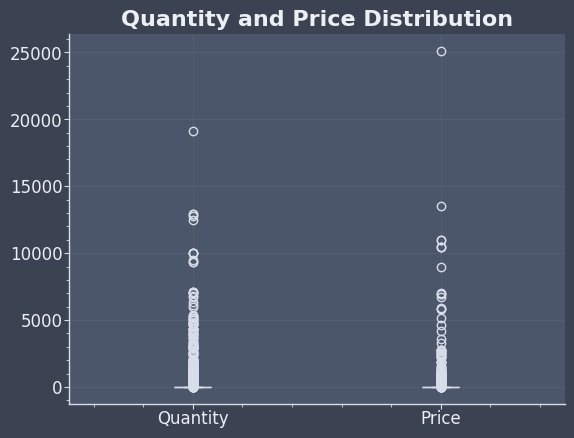

In [62]:
plt.boxplot([fe_df.Quantity, fe_df.Price], patch_artist=True, tick_labels=["Quantity", "Price"])
plt.title("Quantity and Price Distribution")
plt.show()

### Categorical Feature Analysis

Do people buy more from certain countries? Which ones buy the most?

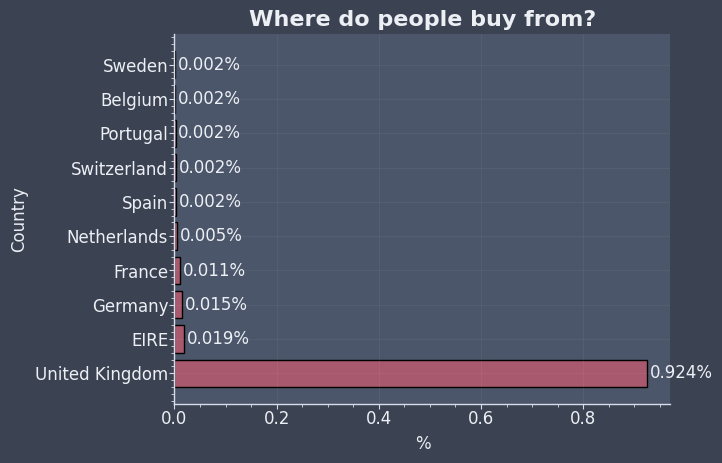

In [63]:
top_country_perc_counts = fe_df.Country.value_counts(normalize=True).nlargest(10)

top_country_bar = plt.barh(top_country_perc_counts.index, top_country_perc_counts.values, edgecolor="black", color="#a8596d")
plt.bar_label(top_country_bar, padding=2, fmt="%1.3f%%")
plt.xlabel("%")
plt.ylabel("Country")
plt.title("Where do people buy from?")
plt.show()

Which are the most bought products (based on description)? 

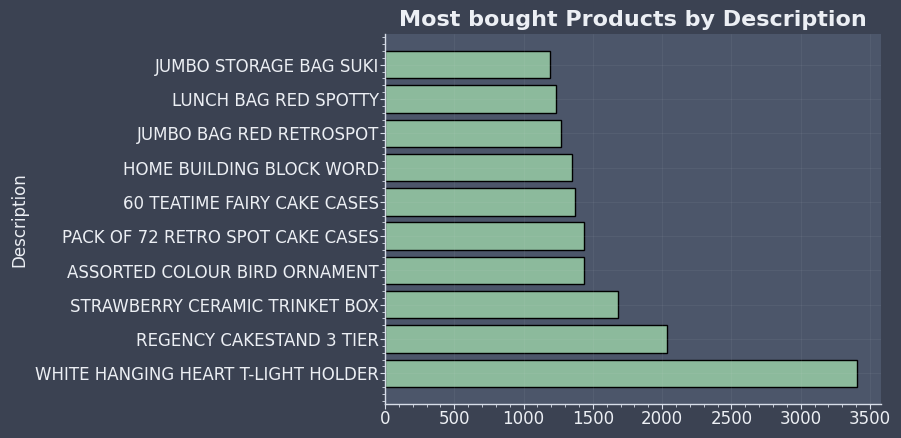

In [64]:
most_bought_products = fe_df.Description.value_counts().nlargest(10)

plt.barh(most_bought_products.index, most_bought_products.values, edgecolor="black", color="#8cba9c")
plt.ylabel("Description")
plt.title("Most bought Products by Description")
plt.show()

# Customer Segmentation Dataframe

In [65]:
# look at the df
cust_segm_df.head()

,Customer ID,Frequency,Monetary,AvgQuantityPerLine,TotalItems,UniqueProducts,Recency,AvgOrderValue,ItemsPerOrder,Country
0,12346,11,372.859985,2.121212,70,26,164,33.896362,6.363636,United Kingdom
1,12347,2,1323.320068,11.661972,828,70,2,661.660034,414.000000,Iceland
2,12348,1,222.160019,18.650000,373,20,73,222.160019,373.000000,Finland
3,12349,3,2671.139893,9.735294,993,90,42,890.379964,331.000000,Italy
4,12351,1,300.929993,12.428571,261,21,10,300.929993,261.000000,Unspecified


In [66]:
# info
cust_segm_df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 4312 entries, 0 to 4311
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Customer ID         4312 non-null   Int64   
 1   Frequency           4312 non-null   int64   
 2   Monetary            4312 non-null   float32 
 3   AvgQuantityPerLine  4312 non-null   float64 
 4   TotalItems          4312 non-null   int64   
 5   UniqueProducts      4312 non-null   int64   
 6   Recency             4312 non-null   int64   
 7   AvgOrderValue       4312 non-null   float64 
 8   ItemsPerOrder       4312 non-null   float64 
 9   Country             4312 non-null   category
dtypes: Int64(1), category(1), float32(1), float64(3), int64(4)
memory usage: 295.5 KB


In [67]:
# shape
cust_segm_df.shape

(4312, 10)

## Customer Segmentation Dataframe EDA

In [68]:
# basic stats
cust_segm_df.describe(include="number").round(2)

,Customer ID,Frequency,Monetary,AvgQuantityPerLine,TotalItems,UniqueProducts,Recency,AvgOrderValue,ItemsPerOrder
count,4312.0,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00,4312.00
mean,15349.29,4.46,2040.41,21.50,1280.05,63.65,90.17,376.37,254.62
std,1701.2,8.17,8911.76,115.06,6457.93,85.76,96.86,492.36,1554.08
min,12346.0,1.00,2.95,1.00,1.00,1.00,0.00,2.95,1.00
25%,13882.5,1.00,307.19,5.28,156.00,17.00,17.00,179.49,89.00
50%,15350.5,2.00,701.61,9.36,380.00,38.00,52.00,285.05,150.89
75%,16834.25,5.00,1714.93,14.26,992.00,79.25,135.00,421.48,255.05
max,18287.0,205.00,349164.34,4460.29,220600.00,1741.00,373.00,11880.84,87167.00


### Numerical Feature Analysis

How much do people spend? How does the distribution look like?

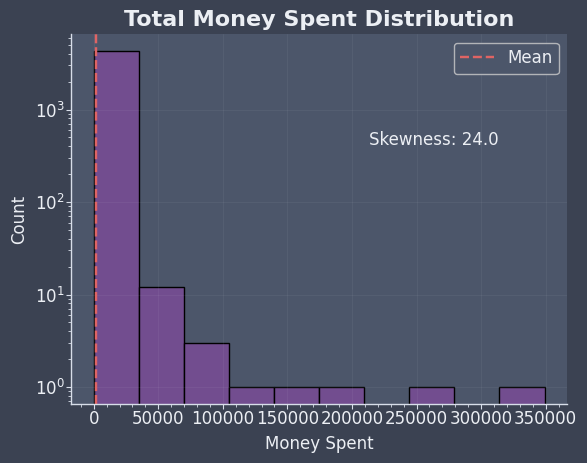

In [69]:
monetary_stats = cust_segm_df.Monetary.agg(["mean", "skew"]).round(2)

plt.hist(cust_segm_df.Monetary, edgecolor="black", color="#724d8f")
plt.axvline(monetary_stats.iloc[0], linestyle="--", color="#df6464", label="Mean")
plt.annotate(f"Skewness: {monetary_stats["skew"]}", xy=(0.60, 0.70), xycoords="axes fraction")
plt.xlabel("Money Spent")
plt.ylabel("Count")
plt.title("Total Money Spent Distribution")
plt.yscale("log")
plt.legend()
plt.show()

Do people tend to purchase many items per order?

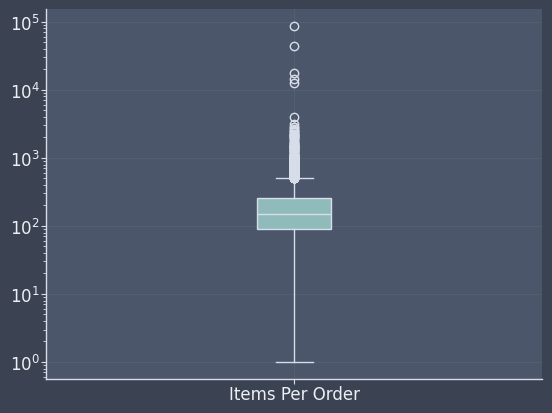

In [70]:
plt.boxplot([cust_segm_df.ItemsPerOrder], patch_artist=True, tick_labels=["Items Per Order"])
plt.yscale("log")
plt.show()

How is average quantity per transaction distributed? Also, do people buy many unique products or prefer the same ones?

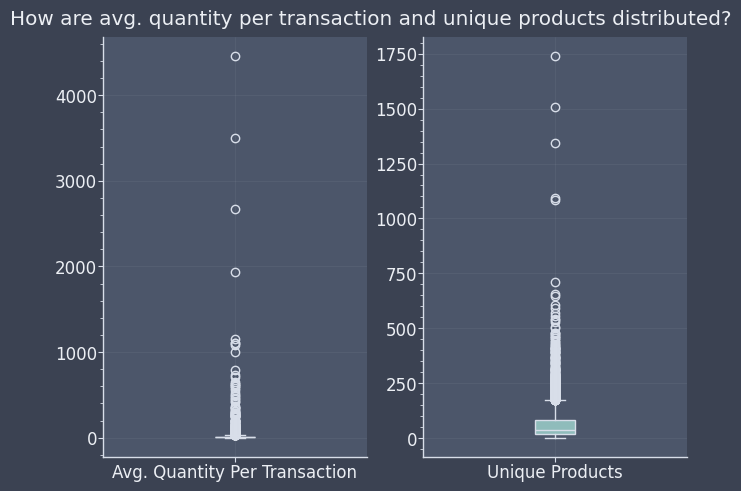

In [71]:
data = [cust_segm_df.AvgQuantityPerLine.values, cust_segm_df.UniqueProducts.values]
labels = ["Avg. Quantity Per Transaction", "Unique Products"]

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True)

for i in range(2):
    axes[i].boxplot([data[i]], patch_artist=True, tick_labels=[labels[i]])

plt.suptitle("How are avg. quantity per transaction and unique products distributed?")
plt.show()

Do people who buy more items spend more per order, on average?

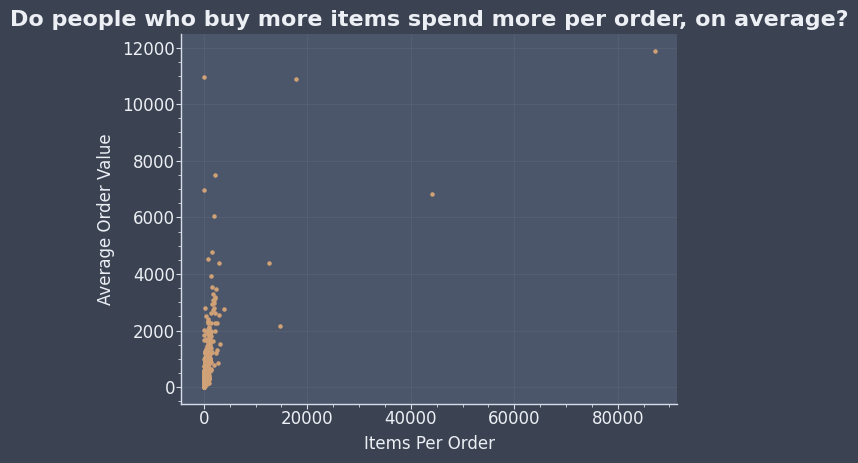

In [72]:
plt.scatter(cust_segm_df.ItemsPerOrder, cust_segm_df.AvgOrderValue, s=5, color="#d0a176")
plt.xlabel("Items Per Order")
plt.ylabel("Average Order Value")
plt.title("Do people who buy more items spend more per order, on average?")
plt.show()

Do people who place more distinct orders / purchase more frequently spend more money?

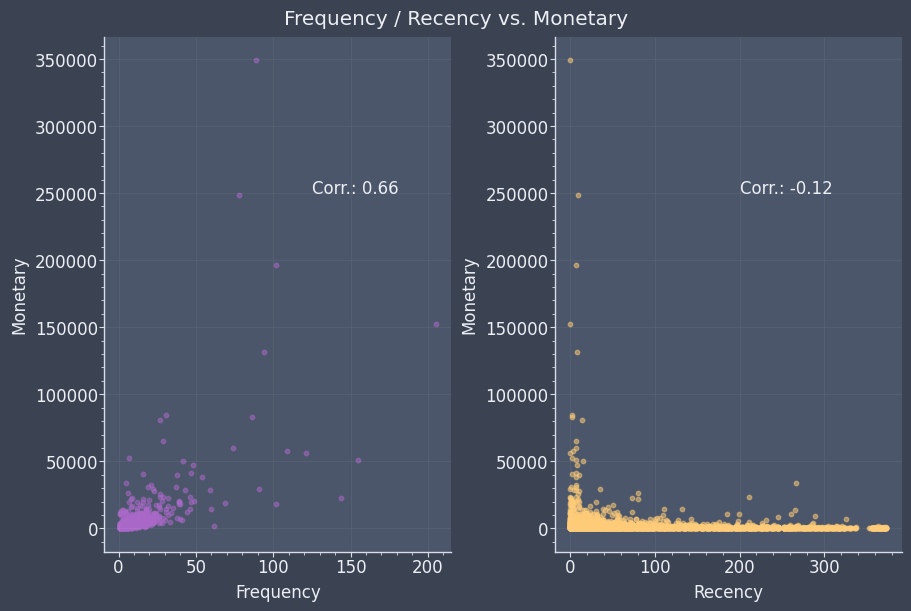

In [73]:
freq_mon_corr = cust_segm_df.Frequency.corr(cust_segm_df.Monetary)
rec_mon_corr = cust_segm_df.Recency.corr(cust_segm_df.Monetary)

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(9, 6))

axes[0].scatter(cust_segm_df.Frequency, cust_segm_df.Monetary, alpha=0.5, s=10, color="#aa69c9")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Monetary")
axes[0].text(x=125, y=250_000, s=f"Corr.: {round(freq_mon_corr, 2)}")

axes[1].scatter(cust_segm_df.Recency, cust_segm_df.Monetary, alpha=0.5, s=10, color="#ffcc79")
axes[1].set_xlabel("Recency")
axes[1].set_ylabel("Monetary")
axes[1].text(x=200, y=250_000, s=f"Corr.: {round(rec_mon_corr, 2)}")

plt.suptitle("Frequency / Recency vs. Monetary")
plt.show()

### Categorical Feature Analysis

Do people delay purchases more in certain countries, on average?

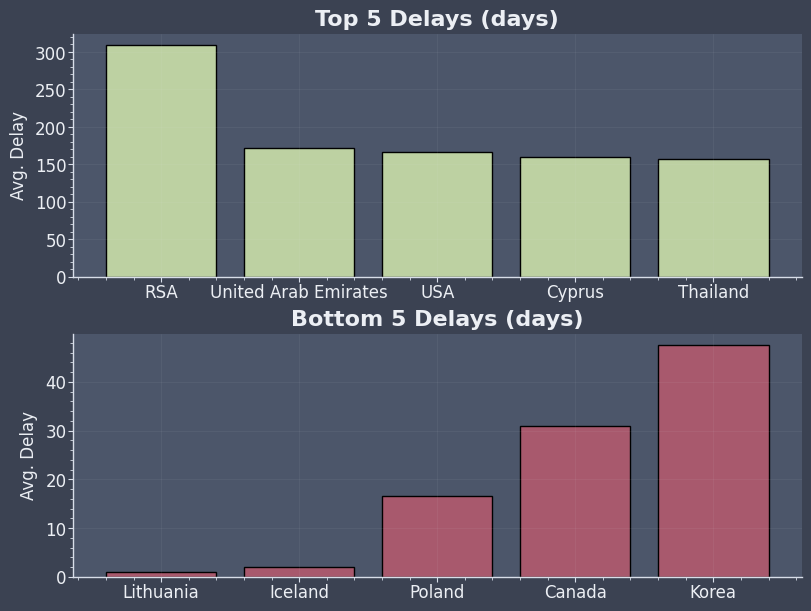

In [74]:
recency_top_five = cust_segm_df.groupby("Country").Recency.mean().nlargest(5)
recency_bottom_five = cust_segm_df.groupby("Country").Recency.mean().nsmallest(5)

fig, axes = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(8, 6))

axes[0].bar(recency_top_five.index, recency_top_five.values, color="#bdd1a2", edgecolor="black")
axes[0].set_title("Top 5 Delays (days)")
axes[0].set_ylabel("Avg. Delay")
axes[1].bar(recency_bottom_five.index, recency_bottom_five.values, color="#a8596d", edgecolor="black")
axes[1].set_title("Bottom 5 Delays (days)")
axes[1].set_ylabel("Avg. Delay")
plt.show()

Since UK is the dominant country, what are its statistics?

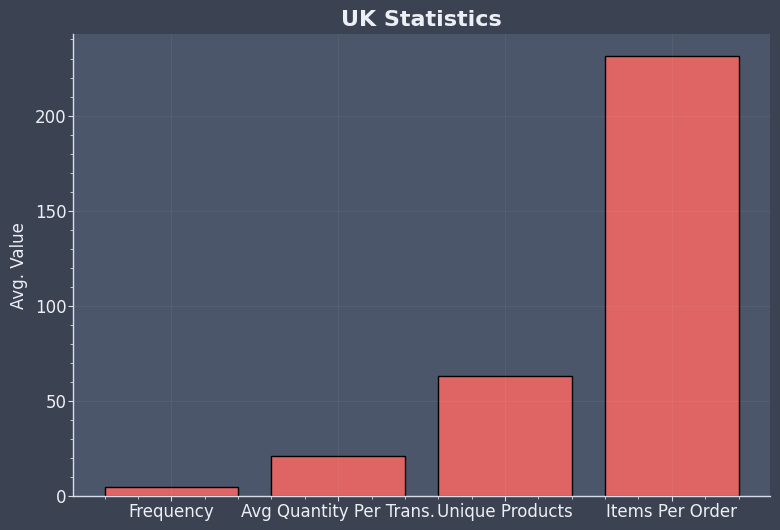

In [75]:
uk_stats = cust_segm_df[cust_segm_df.Country == "United Kingdom"][["Frequency", "AvgQuantityPerLine", "UniqueProducts", "ItemsPerOrder"]].mean().round(2)
uk_stats_labels = ["Frequency", "Avg Quantity Per Trans.", "Unique Products", "Items Per Order"]

plt.figure(figsize=(9, 6))
plt.bar(uk_stats_labels, uk_stats.values, color="#df6464", edgecolor="black")
plt.title("UK Statistics")
plt.ylabel("Avg. Value")
plt.show()

Do people spend more in certain countries, in total? We look at the most frequent countries in the dataset

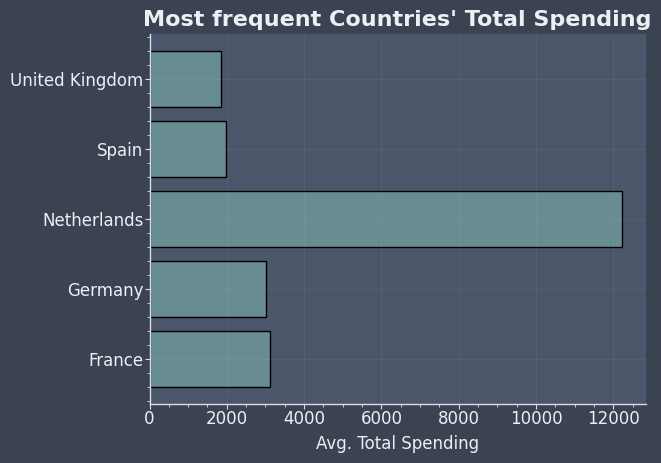

In [76]:
top_countries = cust_segm_df.groupby("Country").size().nlargest(5)
top_countries_monetary_mean = cust_segm_df[cust_segm_df.Country.isin(top_countries.index)].groupby("Country").Monetary.mean()

plt.barh(top_countries_monetary_mean.index, top_countries_monetary_mean.values, edgecolor="black", color="#678c92")
plt.xlabel("Avg. Total Spending")
plt.title("Most frequent Countries' Total Spending")
plt.show()

### Correlation Analysis

Which are the most correlated numerical features?

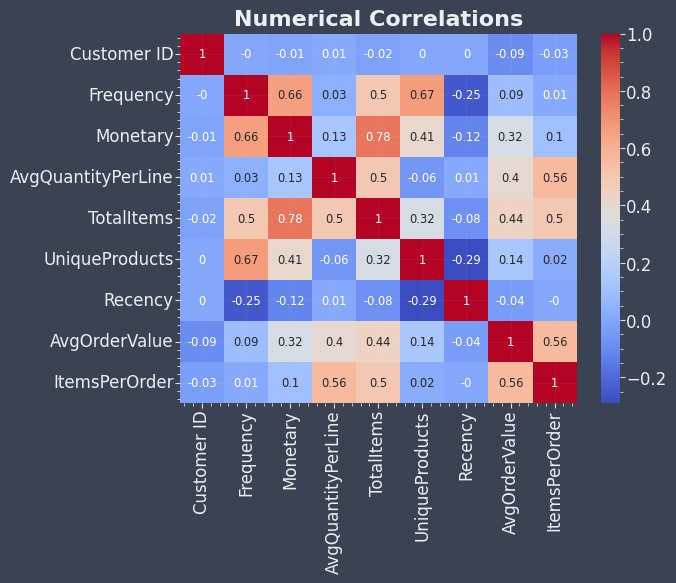

In [77]:
cust_num_corrs = cust_segm_df.corr(numeric_only=True).round(2)

sns.heatmap(cust_num_corrs, cmap="coolwarm", annot=True, annot_kws={"fontsize": "x-small"})
plt.title("Numerical Correlations")
plt.show()

# Exploratory Data Analysis Conclusions

Exploratory Data Analysis Conclusions
MASTER DATAFRAME ANALYSIS
1.	Missing Values Analysis: 
-	Not many customer IDs are missing in the dataset, accounting for 17.1% of it. Transactions without a customer ID have a higher average revenue (≈£22) than transactions linked to identifiable customers (≈£14).
2.	Numerical Feature Analysis:
-	Some months generate more revenue than others. For instance, November total revenue reaches more than £1.4 million, which is more than double the February’s amount of ≈£550 thousand.
-	Quantity and price distributions contain numerous extreme values, suggesting the presence of bulk purchases and unusually expensive products.
3.	Categorical Feature Analysis: 
-	Most transactions (92.4%) are based in the UK, which suggests that the online retail UK company sells most of its products in the same country. Though the UK is the dominant country, others also account for a small part of total transactions: EIRE (1.19%), Germany (1.5%) and France (1.1%).


CUSTOMER SEGMENTATION DATAFRAME ANALYSIS
1.	Numerical Feature Analysis:
-	Total money spent distribution is right-skewed, suggested by the skewness value of 24. This indicates that some customers pay high prices for all the products bought.
-	Average quantity per transaction and unique products histograms have many outliers, according to the data. This indicates that there are people buying many items per transaction, on average, and others prefer to buy many unique products.
-	People who buy more items per order don’t necessarily spend more, according to the data. Many people purchase relatively low items but have a high average order value (reaching more than £6000 sometimes).
2.	Categorical Feature Analysis:
-	RSA, United Arab Emirates and USA are the top countries that, on average, delay the most when it comes to purchases. To note, the data is heavily weighted towards UK, therefore there aren’t many country-specific transactions other than the UK. As a result, meaningful conclusions can’t be reached.
-	Taking into consideration the most common countries in the dataset (UK, Spain, Netherlands, Germany and France), customers from the Netherlands exhibit the highest average spending per customer.

3.	Correlation Analysis:
Some customer-related features are strongly correlated while others don’t show significant correlation values. Some to note are:
-	The number of total items purchased is strongly correlated to total money spent across all purchases (0.78).
-	Recency shows a weak negative relationship with spending (-0.12), suggesting that more recently active customers tend to spend slightly more.
-	Total money spent is also somewhat correlated with how many distinct orders a customer has placed (0.66).